# GFW threshold matching to ASTD
The notebook goes through the GFW matching of fishing vessels on ASTD

We compare the GFW to the ASTD fishing vessels paths for each month to find associated mmsi - shipid

## The comparison is done with data aggregated day by day, over multiple years

In [1]:
from backend import *

gfw_path = "D:/Stockage/GFW/"
astd_path = r"D:\Stockage\ASTD"
parquet_path = "../../examples/data/"

months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Periods for load_periods
periods = {
    2019: months,
    2020: months
}

In [2]:
df_ASTD = load_periods('all_segments_periods2019_2020.parquet', source=astd_path, periods= periods, remove_nan_rows="default", usecols="default", progress=True)
df_ASTD = df_ASTD[df_ASTD['astd_cat'].str.contains('Fishing vessels')].copy()
df_ASTD["date_time_utc"] = pd.to_datetime(df_ASTD["date_time_utc"])
display(df_ASTD)

df_GFW = load_periods_gfw('gfw_2019_2020.parquet', source=gfw_path, periods = periods)
df_GFW['date'] = pd.to_datetime(df_GFW['date'])
display(df_GFW)

Loaded period ../../examples/data/all_segments_periods2019_2020.parquet, parameters ignored


,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude
3,1892,2019-01-01 00:00:04+00:00,Russia,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.028629,540,29.700306,70.626442
4,3009,2019-01-01 00:00:04+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1945.192749,371,25.147583,70.990837
7,2946,2019-01-01 00:00:05+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.057516,119,-23.244274,66.155754
11,3034,2019-01-01 00:00:08+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,3.720555,100,-13.740026,65.135429
17,3107,2019-01-01 00:00:14+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.718225,170,-23.810671,64.921066
...,...,...,...,...,...,...,...,...,...,...
85472769,1634,2020-12-31 23:59:51+00:00,Russia,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,1627.817993,364,10.828934,77.686615
85472770,2113,2020-12-31 23:59:51+00:00,Norway,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,993.163025,369,17.505766,74.173950
85472771,70,2020-12-31 23:59:51+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.551000,360,-22.718353,64.037857
85472774,1199,2020-12-31 23:59:54+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.849000,661,-22.425282,63.839603


Loaded data ../../examples/data/gfw_2019_2020.parquet, parameters ignored


,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours
0,2019-01-01,-74.6,-106.5,440347000,0.8363,0.5983
1,2019-01-01,-74.6,-106.3,440347000,0.2288,0.0000
2,2019-01-01,-74.6,-105.7,440347000,0.2599,0.2599
3,2019-01-01,-74.6,-106.4,440347000,0.3008,0.0000
4,2019-01-01,-74.6,-106.6,440347000,1.8158,1.5694
...,...,...,...,...,...,...
110192515,2020-12-31,79.2,8.8,273418680,0.8986,0.8986
110192516,2020-12-31,79.3,8.6,273352280,0.1138,0.1138
110192517,2020-12-31,79.3,8.4,273352280,0.8827,0.7363
110192518,2020-12-31,79.3,8.5,273352280,1.1450,0.9033


## Process GFW

In [3]:
# Define starting and ending time for the grid (max a month)
# df_GFW['month'] = df_GFW['date'].dt.year.astype(str) + '-' + df_GFW['date'].dt.month.astype(str).str.zfill(2)
df_GFW['month'] = df_GFW['date'].dt.to_period('M')

# Converting grid origin to integer (this avoid float issues with imprecisions)
df_GFW["grid_lon"] = (df_GFW["cell_ll_lon"] * 10).astype('int16')
df_GFW["grid_lat"] = (df_GFW["cell_ll_lat"] * 10).astype('int16')

df_GFW

,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours,month,grid_lon,grid_lat
0,2019-01-01,-74.6,-106.5,440347000,0.8363,0.5983,2019-01,-1065,-746
1,2019-01-01,-74.6,-106.3,440347000,0.2288,0.0000,2019-01,-1063,-746
2,2019-01-01,-74.6,-105.7,440347000,0.2599,0.2599,2019-01,-1057,-746
3,2019-01-01,-74.6,-106.4,440347000,0.3008,0.0000,2019-01,-1064,-746
4,2019-01-01,-74.6,-106.6,440347000,1.8158,1.5694,2019-01,-1066,-746
...,...,...,...,...,...,...,...,...,...
110192515,2020-12-31,79.2,8.8,273418680,0.8986,0.8986,2020-12,88,792
110192516,2020-12-31,79.3,8.6,273352280,0.1138,0.1138,2020-12,86,793
110192517,2020-12-31,79.3,8.4,273352280,0.8827,0.7363,2020-12,84,793
110192518,2020-12-31,79.3,8.5,273352280,1.1450,0.9033,2020-12,85,793


In [4]:
# select_subset = False
#
# if select_subset:
#     # get gfw samples
#     gfw_work = (
#         df_GFW
#         .groupby(['mmsi', 'month'], group_keys=False)
#         .sample(frac=0.5, random_state=42)
#     )
#
#     gfw_work.sort_index(inplace=True)
#
# else:
#     # or keep full data
#     gfw_work = df_GFW.copy()

gfw_work = df_GFW.copy()

# Select mmsi with more than a month of data
counts = gfw_work.groupby('mmsi')['month'].nunique()
valid_mmsi = counts[counts > 1].index
gfw_work = gfw_work[gfw_work['mmsi'].isin(valid_mmsi)]

# Filter remove all mmsi with points under europe line - lat = 60:
lat_threshold = 59
if lat_threshold != 0:
    max_point_allowed = 0

    mask = gfw_work['grid_lat'] < lat_threshold * 10
    counts = mask.groupby(gfw_work['mmsi']).sum()

    valid_mmsi = counts[counts <= max_point_allowed].index
    gfw_work = gfw_work[gfw_work['mmsi'].isin(valid_mmsi)]

gfw_work

,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours,month,grid_lon,grid_lat
85360,2019-01-01,59.1,5.4,257020250,24.0144,0.0000,2019-01,54,591
85364,2019-01-01,59.1,5.3,257384820,24.8988,0.0000,2019-01,53,591
85397,2019-01-01,59.2,5.1,235092091,23.7713,0.0000,2019-01,51,592
85400,2019-01-01,59.2,5.2,257024540,23.8500,0.0000,2019-01,52,592
85402,2019-01-01,59.2,5.4,257045160,24.1000,0.0000,2019-01,54,592
...,...,...,...,...,...,...,...,...,...
110192512,2020-12-31,79.2,8.8,273355780,1.4647,1.4647,2020-12,88,792
110192513,2020-12-31,79.2,8.9,273355780,0.5661,0.5661,2020-12,89,792
110192516,2020-12-31,79.3,8.6,273352280,0.1138,0.1138,2020-12,86,793
110192517,2020-12-31,79.3,8.4,273352280,0.8827,0.7363,2020-12,84,793


We're aggregating the positions per day instead of keeping the time spent in each

In [5]:
# Aggregating the data by day and by positions
gfw_work = gfw_work[['mmsi', 'date', 'grid_lat', 'grid_lon', 'month']].drop_duplicates()
gfw_work

,mmsi,date,grid_lat,grid_lon,month
85360,257020250,2019-01-01,591,54,2019-01
85364,257384820,2019-01-01,591,53,2019-01
85397,235092091,2019-01-01,592,51,2019-01
85400,257024540,2019-01-01,592,52,2019-01
85402,257045160,2019-01-01,592,54,2019-01
...,...,...,...,...,...
110192512,273355780,2020-12-31,792,88,2020-12
110192513,273355780,2020-12-31,792,89,2020-12
110192516,273352280,2020-12-31,793,86,2020-12
110192517,273352280,2020-12-31,793,84,2020-12


## Process ASTD

In [6]:
# df_ASTD['month'] = df_ASTD['date_time_utc'].dt.year.astype(str) + '-' + df_ASTD['date_time_utc'].dt.month.astype(str).str.zfill(2)
dt = df_ASTD['date_time_utc'].dt
df_ASTD['month'] = dt.to_period('M')
df_ASTD['date'] = dt.floor('D')

del dt

# Transform ASTD into grids to reduce compute overhead
df_ASTD["grid_lon"] = np.floor(df_ASTD["longitude"] * 10).astype('int16')
df_ASTD["grid_lat"] = np.floor(df_ASTD["latitude"] * 10).astype('int16')

df_ASTD

C:\Users\virtu\AppData\Local\Temp\ipykernel_1380\55727238.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_ASTD_2020['month'] = dt.to_period('M')


,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,month,date,grid_lon,grid_lat
3,1892,2019-01-01 00:00:04+00:00,Russia,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.028629,540,29.700306,70.626442,2019-01,2019-01-01 00:00:00+00:00,297,706
4,3009,2019-01-01 00:00:04+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1945.192749,371,25.147583,70.990837,2019-01,2019-01-01 00:00:00+00:00,251,709
7,2946,2019-01-01 00:00:05+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.057516,119,-23.244274,66.155754,2019-01,2019-01-01 00:00:00+00:00,-233,661
11,3034,2019-01-01 00:00:08+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,3.720555,100,-13.740026,65.135429,2019-01,2019-01-01 00:00:00+00:00,-138,651
17,3107,2019-01-01 00:00:14+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.718225,170,-23.810671,64.921066,2019-01,2019-01-01 00:00:00+00:00,-239,649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85472769,1634,2020-12-31 23:59:51+00:00,Russia,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,1627.817993,364,10.828934,77.686615,2020-12,2020-12-31 00:00:00+00:00,108,776
85472770,2113,2020-12-31 23:59:51+00:00,Norway,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,993.163025,369,17.505766,74.173950,2020-12,2020-12-31 00:00:00+00:00,175,741
85472771,70,2020-12-31 23:59:51+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.551000,360,-22.718353,64.037857,2020-12,2020-12-31 00:00:00+00:00,-228,640
85472774,1199,2020-12-31 23:59:54+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.849000,661,-22.425282,63.839603,2020-12,2020-12-31 00:00:00+00:00,-225,638


In [7]:
# Aggregating the data by day and by positions
df_astd = df_ASTD[['date', 'shipid', 'grid_lat', 'grid_lon', 'month']].drop_duplicates()
display(df_astd)

,date,shipid,grid_lat,grid_lon,month
3,2019-01-01 00:00:00+00:00,1892,706,297,2019-01
4,2019-01-01 00:00:00+00:00,3009,709,251,2019-01
7,2019-01-01 00:00:00+00:00,2946,661,-233,2019-01
11,2019-01-01 00:00:00+00:00,3034,651,-138,2019-01
17,2019-01-01 00:00:00+00:00,3107,649,-239,2019-01
...,...,...,...,...,...
85472637,2020-12-31 00:00:00+00:00,1077,714,433,2020-12
85472654,2020-12-31 00:00:00+00:00,2309,774,105,2020-12
85472697,2020-12-31 00:00:00+00:00,2165,773,112,2020-12
85472731,2020-12-31 00:00:00+00:00,555,697,191,2020-12


## Merge (inner join) both by position and time

In [8]:
gfw_work['date'] = pd.to_datetime(gfw_work['date'], utc=True)
df_astd['date'] = pd.to_datetime(df_astd['date'], utc=True)

merged = gfw_work.merge(df_astd, on=["grid_lon", "grid_lat", "date", "month"], how="inner")
merged

,mmsi,date,grid_lat,grid_lon,month,shipid
0,231030000,2019-01-01 00:00:00+00:00,614,-66,2019-01,9675
1,231031000,2019-01-01 00:00:00+00:00,615,-67,2019-01,9675
2,231326000,2019-01-01 00:00:00+00:00,615,-67,2019-01,9675
3,231327000,2019-01-01 00:00:00+00:00,615,-67,2019-01,9675
4,231037000,2019-01-01 00:00:00+00:00,616,-70,2019-01,2418
...,...,...,...,...,...,...
5786549,273355780,2020-12-31 00:00:00+00:00,792,88,2020-12,1772
5786550,273355780,2020-12-31 00:00:00+00:00,792,89,2020-12,2150
5786551,273352280,2020-12-31 00:00:00+00:00,793,86,2020-12,1772
5786552,273352280,2020-12-31 00:00:00+00:00,793,84,2020-12,1772


## Get shipids per mmsi

In [9]:
# Number of matched points per shipid, per mmsi, per month
match_size = (
    merged
    .groupby(['mmsi', 'month', 'shipid'])
    .agg(match_n_mmsi=('mmsi', 'size'))
    .reset_index()
)

# Total ASTD number of points per shipid, per month
astd_total = (
    df_astd
    .groupby(['shipid', 'month'])
    .agg(astd_n_ship=('shipid', 'size'))
    .reset_index()
)

# Total selected GFW number of points per mmsi, per month
gfw_total = (
    gfw_work
    .groupby(['mmsi', 'month'])
    .agg(gfw_n_mmsi=('mmsi', 'size'))
    .reset_index()
)

# Merge all
merged_scoring = (
    match_size
    .merge(astd_total, on=['shipid', 'month'], how='inner')
    .merge(gfw_total, on=['mmsi', 'month'], how='inner')
)

# Compute scores
merged_scoring['ratio_gfw'] = merged_scoring['match_n_mmsi'] / merged_scoring['gfw_n_mmsi'] # Proportion of matched gfw points
merged_scoring['ratio_astd'] = merged_scoring['match_n_mmsi'] / merged_scoring['astd_n_ship'] # Proportion of matched astd points

merged_scoring['score'] = merged_scoring['ratio_gfw'] + merged_scoring['ratio_astd']
merged_scoring['max_score_mmsi'] = merged_scoring.groupby(['mmsi', 'month'])['score'].transform('max')
merged_scoring['max_score_shipid'] = merged_scoring.groupby(['shipid', 'month'])['score'].transform('max')

merged_scoring = merged_scoring[
    ## Takes highest mmsi for a shipid, that's also the highest shipid for a mmsi
    (merged_scoring['score'] == merged_scoring['max_score_mmsi'])
    & (merged_scoring['score'] == merged_scoring['max_score_shipid'])
]

merged_scoring

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid
8,219005983,2019-03,2367,4,229,29,0.137931,0.017467,0.155398,0.155398,0.155398
13,219005983,2019-04,3984,1,279,1,1.000000,0.003584,1.003584,1.003584,1.003584
46,219005983,2019-10,2607,8,282,153,0.052288,0.028369,0.080656,0.080656,0.080656
77,219005983,2020-02,3242,6,345,29,0.206897,0.017391,0.224288,0.224288,0.224288
91,219005983,2020-04,2463,7,349,32,0.218750,0.020057,0.238807,0.238807,0.238807
...,...,...,...,...,...,...,...,...,...,...,...
483875,331781000,2019-07,4278,742,793,961,0.772112,0.935687,1.707800,1.707800,1.707800
483913,331781000,2019-08,4545,862,944,1067,0.807873,0.913136,1.721008,1.721008,1.721008
483933,331781000,2019-09,4478,550,568,641,0.858034,0.968310,1.826344,1.826344,1.826344
484026,331784000,2020-07,3802,2,808,4,0.500000,0.002475,0.502475,0.502475,0.502475


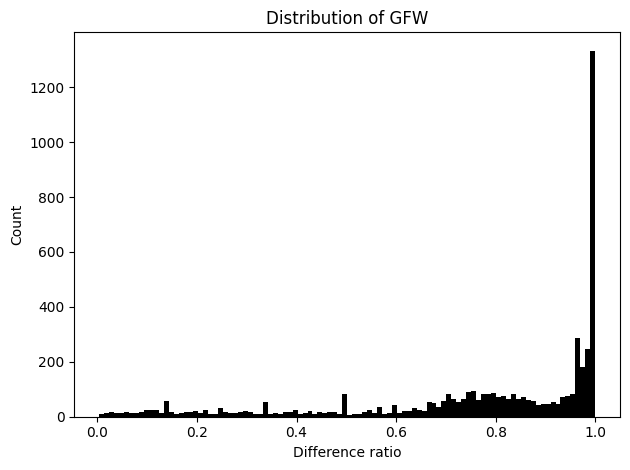

In [10]:
plt.hist(merged_scoring['ratio_gfw'], bins=100, color='black')
plt.xlabel("Difference ratio")
plt.ylabel("Count")
plt.title("Distribution of GFW")
plt.tight_layout()
plt.show()

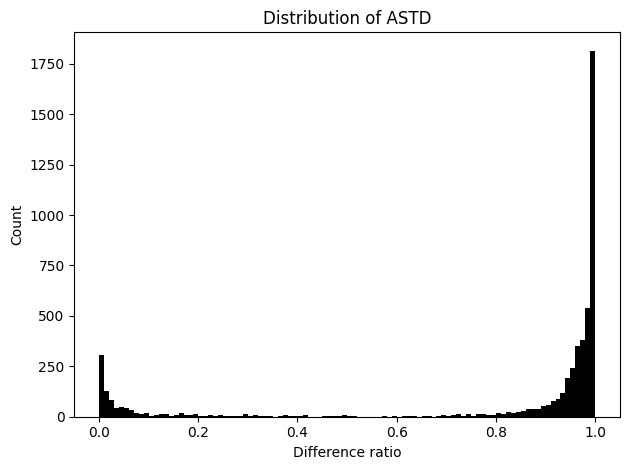

In [11]:
plt.hist(merged_scoring['ratio_astd'], bins=100, color='black')
plt.xlabel("Difference ratio")
plt.ylabel("Count")
plt.title("Distribution of ASTD")
plt.tight_layout()
plt.show()

In [12]:
# Thresholds
t_astd = 0.9
t_gfw_high = 0.6
t_gfw_low = 0.8
n_small = 20

mask_merged = (
    ( # = allowed missing astd datapoints
        ((merged_scoring['match_n_mmsi'] < n_small) & (merged_scoring['ratio_gfw'] >= t_gfw_low)) | # Ratio has to bet_gfw_low with tracks with less than n_small points
        ((merged_scoring['match_n_mmsi'] >= n_small) & (merged_scoring['ratio_gfw'] >= t_gfw_high)) # Else, check if ration is higher than t_gfw_high
    )
    # = allowed missing gfw datapoints
    & (merged_scoring['ratio_astd'] >= t_astd)
)

merged_scores = merged_scoring[mask_merged].copy()
merged_scores = merged_scores.sort_values(by='gfw_n_mmsi', ascending=False).reset_index(drop=True)

merged_scores

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid
0,273217010,2020-04,1952,1426,1451,1678,0.849821,0.982771,1.832592,1.832592,1.832592
1,276806000,2020-10,641,1332,1355,1577,0.844642,0.983026,1.827668,1.827668,1.827668
2,273451570,2020-09,324,1274,1290,1556,0.818766,0.987597,1.806363,1.806363,1.806363
3,258535000,2020-10,1219,1301,1370,1513,0.859881,0.949635,1.809516,1.809516,1.809516
4,251153000,2019-06,2031,1093,1145,1490,0.733557,0.954585,1.688142,1.688142,1.688142
...,...,...,...,...,...,...,...,...,...,...,...
3538,251153000,2020-06,1557,3,3,3,1.000000,1.000000,2.000000,2.000000,2.000000
3539,257046460,2020-10,478,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000
3540,231189000,2020-05,22009,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000
3541,259616000,2019-08,21852,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000


In [13]:
df = merged_scores.copy()

# Remove multiple shipid for one mmsi (in case many have the same max score)
mask = df.groupby(['mmsi', 'month'])['shipid'].transform('nunique') == 1

# Remove multiple mmsi for one shipid
mask1 = df.groupby(['shipid', 'month'])['mmsi'].transform('nunique') == 1


df = df[mask1 & mask]
df = df.sort_values(by='match_n_mmsi', ascending=False).reset_index(drop=True)


print("Total size (unique shipid):", df.shape[0])
print("Total mmsi :", df['mmsi'].nunique())

df_pct = ( # Pourcentage, of how many mmsi have 12, 11, 10 ... matched months
    df
    .groupby('mmsi')['month']
    .nunique()
    .value_counts(normalize=True)
    .mul(100)
    .rename('percent')
    .reset_index(name='percent')
    .rename(columns={'index': 'n_months'})
)

display(df_pct)

df


Total size (unique shipid): 2430
Total mmsi : 187


,month,percent
0,1,18.716578
1,22,16.042781
2,23,6.951872
3,17,6.417112
4,18,6.417112
5,19,6.417112
6,2,6.417112
7,21,5.347594
8,20,3.743316
9,16,3.208556


,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid
0,273217010,2020-04,1952,1426,1451,1678,0.849821,0.982771,1.832592,1.832592,1.832592
1,276806000,2020-10,641,1332,1355,1577,0.844642,0.983026,1.827668,1.827668,1.827668
2,258535000,2020-10,1219,1301,1370,1513,0.859881,0.949635,1.809516,1.809516,1.809516
3,273451570,2020-09,324,1274,1290,1556,0.818766,0.987597,1.806363,1.806363,1.806363
4,277558000,2020-11,2082,1181,1192,1349,0.875463,0.990772,1.866235,1.866235,1.866235
...,...,...,...,...,...,...,...,...,...,...,...
2425,251153000,2020-06,1557,3,3,3,1.000000,1.000000,2.000000,2.000000,2.000000
2426,257046460,2020-10,478,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000
2427,231189000,2020-05,22009,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000
2428,259616000,2019-08,21852,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000


In [27]:
# Convert to a dictionnary - makes it easier to get the shipid for each mmsi
result = {}

for _, row in df.iterrows():
    mmsi = row['mmsi']
    month = row['month']
    shipid = row['shipid']
    result.setdefault(mmsi, {})[month] = shipid


# Save dictionnary to json
# with open(parquet_path + "gfw_threshmatch.json", "w") as f:
#     json.dump(result, f, indent=4)

# Save into csv
df.to_csv(parquet_path + f"gfw_threshmatch2019_2020.{lat_threshold}{[t_astd,t_gfw_low,t_gfw_high,n_small]}.csv", index=False)

## Display examples

In [16]:
mmsi = 257032830

display(gfw_work[gfw_work['mmsi']==mmsi])

,mmsi,date,grid_lat,grid_lon,month
88486894,257032830,2020-08-28 00:00:00+00:00,623,58,2020-08
88638997,257032830,2020-08-29 00:00:00+00:00,623,58,2020-08
88790544,257032830,2020-08-30 00:00:00+00:00,623,58,2020-08
88967819,257032830,2020-08-31 00:00:00+00:00,623,58,2020-08
89180398,257032830,2020-09-01 00:00:00+00:00,623,58,2020-09
...,...,...,...,...,...
110191951,257032830,2020-12-31 00:00:00+00:00,743,224,2020-12
110191952,257032830,2020-12-31 00:00:00+00:00,743,225,2020-12
110191953,257032830,2020-12-31 00:00:00+00:00,743,221,2020-12
110191954,257032830,2020-12-31 00:00:00+00:00,743,223,2020-12


In [21]:
top_ships = result[mmsi]
# mmsi=273418680
# top_ships = {'2020-02' : 2915}

top_ships_df = pd.DataFrame(list(top_ships.items()), columns=['month', 'shipid'])

col_lat_astd = 'grid_lat'
col_lon_astd = 'grid_lon'

col_lat_gfw = 'grid_lat'
col_lon_gfw = 'grid_lon'

# To plot astd origin point or grids + gfw sample or not
origin = True

if origin:

    col_lat_astd = 'latitude'
    col_lon_astd = 'longitude'

    # col_lat_gfw = 'cell_ll_lat'
    # col_lon_gfw = 'cell_ll_lon'
    df1 = df_ASTD.merge(top_ships_df, on=['shipid', 'month'], how='inner')
    df1['track_id'] = mmsi
    df2 = df_GFW[df_GFW['mmsi']==mmsi].merge(top_ships_df, on=['month'], how='inner')

else:
    df2 = gfw_work[(gfw_work['mmsi']==mmsi)].merge(top_ships_df, on=['month'], how='inner')
    df1 = df_astd.merge(top_ships_df, on=['shipid', 'month'], how='inner')

df2 = df2.drop_duplicates(subset=[col_lon_gfw, col_lat_gfw])

display(df2)
df1

,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours,month,grid_lon,grid_lat,shipid
0,2020-09-01,62.3,5.8,257032830,24.0002,0.0,2020-09,58,623,2017
4,2020-09-05,62.3,6.0,257032830,0.4144,0.0,2020-09,60,623,2017
5,2020-09-05,62.3,6.3,257032830,0.0208,0.0,2020-09,63,623,2017
6,2020-09-05,62.3,6.1,257032830,4.4538,0.0,2020-09,61,623,2017
8,2020-09-05,62.3,6.2,257032830,0.3886,0.0,2020-09,62,623,2017
9,2020-09-05,62.4,6.0,257032830,1.1188,0.0,2020-09,60,624,2017
10,2020-09-05,62.4,5.9,257032830,0.2288,0.0,2020-09,59,624,2017
11,2020-09-05,62.4,5.8,257032830,0.2386,0.0,2020-09,58,624,2017
12,2020-09-06,62.2,6.0,257032830,0.2166,0.0,2020-09,60,622,2017


,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,month,date,grid_lon,grid_lat,track_id
0,2017,2020-09-01 00:06:35+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.329,721,5.842935,62.323898,2020-09,2020-09-01 00:00:00+00:00,58,623,257032830
1,2017,2020-09-01 00:21:34+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,3.227,899,5.842890,62.323917,2020-09,2020-09-01 00:00:00+00:00,58,623,257032830
2,2017,2020-09-01 00:27:35+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,3.382,361,5.842913,62.323887,2020-09,2020-09-01 00:00:00+00:00,58,623,257032830
3,2017,2020-09-01 00:42:35+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.816,900,5.842947,62.323895,2020-09,2020-09-01 00:00:00+00:00,58,623,257032830
4,2017,2020-09-01 00:51:34+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,3.897,539,5.842885,62.323872,2020-09,2020-09-01 00:00:00+00:00,58,623,257032830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6522,2017,2020-09-30 23:30:01+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,2.416,360,5.842900,62.323868,2020-09,2020-09-30 00:00:00+00:00,58,623,257032830
6523,2017,2020-09-30 23:36:02+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.346,361,5.842893,62.323868,2020-09,2020-09-30 00:00:00+00:00,58,623,257032830
6524,2017,2020-09-30 23:42:12+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,2.334,370,5.842906,62.323887,2020-09,2020-09-30 00:00:00+00:00,58,623,257032830
6525,2017,2020-09-30 23:48:40+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.518,388,5.842916,62.323887,2020-09,2020-09-30 00:00:00+00:00,58,623,257032830


In [23]:
res = 0.1

pio.renderers.default = "browser"
# pio.renderers.default = "notebook"

# Plot ASTD
if origin:
    fig = tb.plot_ship_tracks(
        df1,
        track_ids=[mmsi],
        color_by="track_id",
        show_points=True,
        show_start_end=True,
        map_style="open-street-map",
        zoom=4,
    )

else:
    fig = go.Figure()
    lons_all = []
    lats_all = []

    for _, row in df1.iterrows():
        lon0 = row[col_lon_astd] * res
        lat0 = row[col_lat_astd] * res

        lons_all += [lon0, lon0+0.1, lon0+0.1, lon0, lon0, None]
        lats_all += [lat0, lat0, lat0+0.1, lat0+0.1, lat0, None]

    fig.add_trace(go.Scattermap(
        lon=lons_all,
        lat=lats_all,
        mode="lines",
        line=dict(color="blue", width=2),
        name="Cells df1"
    ))

#GFW plot grids
lons_all = []
lats_all = []

for _, row in df2.iterrows():
    lon0 = row[col_lon_gfw] * res
    lat0 = row[col_lat_gfw] * res

    lons_all += [lon0, lon0+0.1, lon0+0.1, lon0, lon0, None]
    lats_all += [lat0, lat0, lat0+0.1, lat0+0.1, lat0, None]


fig.add_trace(go.Scattermap(
    lon=lons_all,
    lat=lats_all,
    mode="lines",
    line=dict(color="red", width=1),
    name="Cells df2"
))

fig.update_layout(
    map=dict(
        style="open-street-map",
        zoom=3,
        center=dict(lat=df1[col_lat_astd].mean(),
                    lon=df1[col_lon_astd].mean())
    ),
    title=f"{mmsi} for top shipids"
)

# tb.export_figure(fig, f"GFW2ASTD_{mmsi}.html")

fig.show()